# Assignment 8: Supervised Learning Classification

# Student Name: Mohammad Tamim Hamkar

Step 1: Import Libraries

In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

Step 2: Load the Dataset

In [2]:
# Load the Dataset

cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Step 3: Check and Clean the Data

In [4]:
# Check and Clean the Data

print("Dataset shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.info()

Dataset shape: (569, 31)

Missing values: 0
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error        

Step 4: Check Class Distribution

target
1    357
0    212
Name: count, dtype: int64


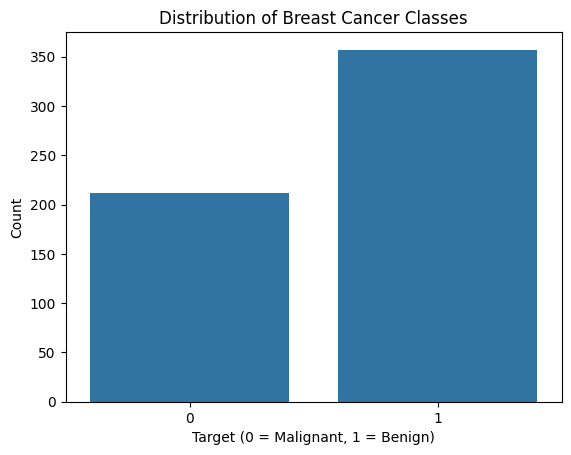

In [5]:
# Check Class Distribution

print(df['target'].value_counts())

sns.countplot(x='target', data=df)
plt.title('Distribution of Breast Cancer Classes')
plt.xlabel('Target (0 = Malignant, 1 = Benign)')
plt.ylabel('Count')
plt.show()

Step 5: Correlation Between Features

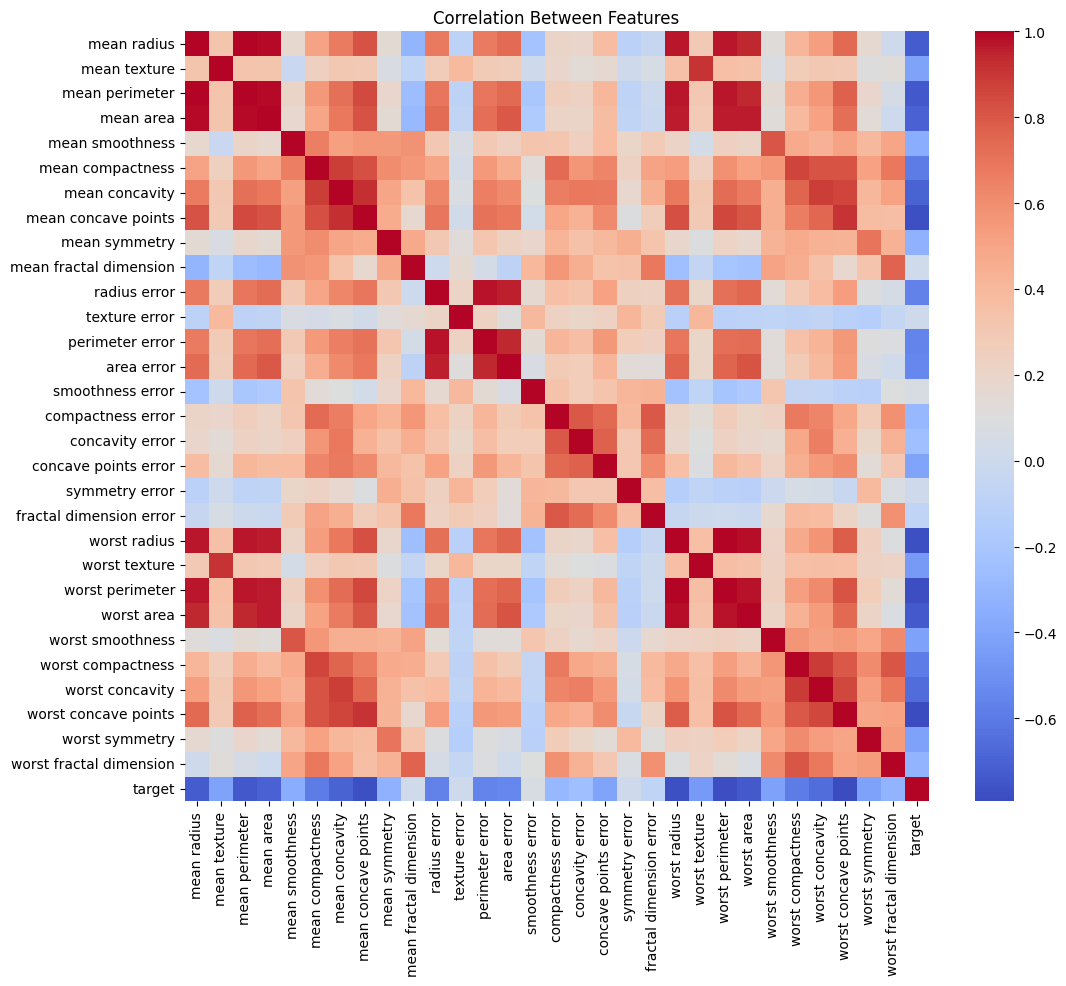

In [6]:
# Correlation Analysis

plt.figure(figsize=(12, 10))

correlation = df.corr()

sns.heatmap(correlation, cmap='coolwarm')

plt.title('Correlation Between Features')
plt.show()

Step 6: Split the Data

In [7]:
# Split the Data into Training and Testing Sets

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


Step 7: Scale the Features

In [8]:
# Scale the Features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


Step 8: Train Two Classification Models

In [9]:
# Train Logistic Regression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Train Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


Step 9: Evaluate Both Models

In [10]:
# Evaluate Both Models

# Predictions
log_pred = log_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)

# Logistic Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1-score:", f1_score(y_test, log_pred))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))

Logistic Regression
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1-score: 0.9861111111111112

Random Forest
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1-score: 0.9655172413793104


Step 10: Confusion Matrices

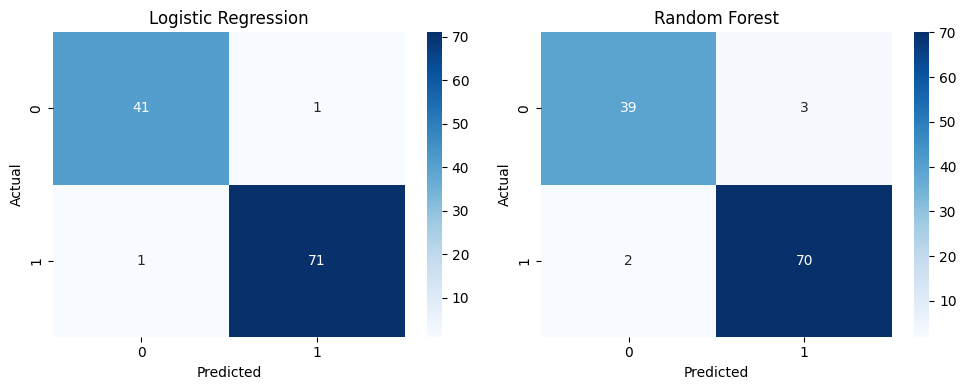

In [11]:
# Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, log_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Step 11: ROC Curve and ROC-AUC

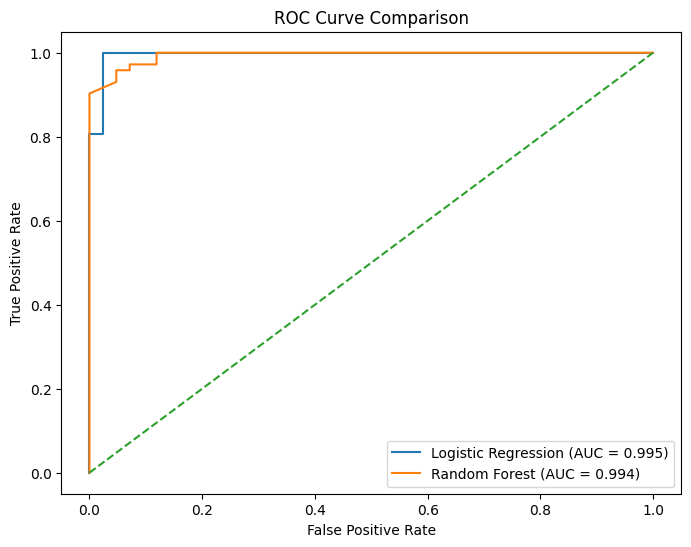

Logistic Regression ROC-AUC: 0.9953703703703703
Random Forest ROC-AUC: 0.9937169312169312


In [12]:
# ROC Curve and ROC-AUC

log_prob = log_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

log_auc = roc_auc_score(y_test, log_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(log_fpr, log_tpr, label=f'Logistic Regression (AUC = {log_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print("Logistic Regression ROC-AUC:", log_auc)
print("Random Forest ROC-AUC:", rf_auc)

## Step 12: Model Interpretation

Both models performed very well on the breast cancer dataset. However, Logistic Regression performed slightly better overall.

Logistic Regression achieved an accuracy of 98.25% and an ROC-AUC score of 0.995, while Random Forest achieved an accuracy of 95.61% and an ROC-AUC score of 0.994.

The confusion matrix also showed that Logistic Regression made only 2 incorrect predictions, compared with 5 incorrect predictions from Random Forest.

Based on these results, I selected Logistic Regression as the best-performing model. It provided the highest overall accuracy while also maintaining strong precision, recall, F1-score, and ROC-AUC performance.

## Step 13: Deployment and Monitoring

The Logistic Regression model could be deployed as a simple web application or API using tools such as Flask or FastAPI. New patient data could be entered into the system, processed using the same scaling method used during training, and then passed to the model to generate a prediction.

After deployment, the model should be monitored regularly to make sure its performance remains accurate and reliable. New incoming data may change over time, which could affect the model's predictions. Performance metrics such as accuracy, precision, recall, and F1-score should be checked periodically.

Because this model deals with breast cancer classification, incorrect predictions could have serious consequences. Therefore, the model should be used as a supporting tool rather than a replacement for medical professionals. The model should also be retrained and tested when enough new data becomes available.

## Step 14: Conclusion

In this project, I used the Breast Cancer dataset to build and compare two supervised learning classification models: Logistic Regression and Random Forest.

After checking and preparing the data, I performed exploratory data analysis, split the dataset into training and testing sets, and applied feature scaling. Both models performed very well, but Logistic Regression achieved the best overall results with an accuracy of 98.25% and an ROC-AUC score of approximately 0.995.

Based on the evaluation metrics and confusion matrix, Logistic Regression was selected as the best model. Overall, this assignment helped me understand how classification models can be trained, evaluated, compared, and prepared for deployment and ongoing monitoring.